# 03 IV Analysis

目标：计算WOE-IV，比较不同IV筛选区间的变量数量和字段来源，为模型实验提供筛选依据。


In [1]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from fraud_detection.utils import load_yaml
from fraud_detection.data import read_ieee_train, split_by_time
from fraud_detection.features import candidate_features, add_missing_indicators, categorical_features, build_feature_system
from fraud_detection.iv import compute_iv_table, select_features

config = load_yaml(PROJECT_ROOT / "configs/base.yaml")
df = read_ieee_train(PROJECT_ROOT / config["data"]["raw_dir"])
train, valid, test, _ = split_by_time(df)
features = candidate_features(train)
train, valid, test, iv_features, indicators = add_missing_indicators(train, valid, test, features)
cats = categorical_features(iv_features)


In [2]:
iv_table, iv_details = compute_iv_table(
    train,
    iv_features,
    cats,
    bins=config["iv"]["bins"],
    max_categories=config["iv"]["max_categories"],
)
risk_system = build_feature_system(train)
iv_table = iv_table.merge(risk_system[["Feature", "FeatureCategory", "RiskMechanism"]], on="Feature", how="left")
display(iv_table.head(30))
iv_table.to_csv(PROJECT_ROOT / "outputs/tables/notebook_iv_summary.csv", index=False, encoding="utf-8-sig")


,Feature,IV,FeatureCategory,RiskMechanism
0,V258,0.805640,Vesta聚合统计特征,批量聚集与实体关联异常
1,V257,0.768245,Vesta聚合统计特征,批量聚集与实体关联异常
2,V189,0.753989,Vesta聚合统计特征,批量聚集与实体关联异常
3,V201,0.748800,Vesta聚合统计特征,批量聚集与实体关联异常
4,V200,0.735645,Vesta聚合统计特征,批量聚集与实体关联异常
5,V199,0.733257,Vesta聚合统计特征,批量聚集与实体关联异常
6,V188,0.728831,Vesta聚合统计特征,批量聚集与实体关联异常
7,V190,0.724744,Vesta聚合统计特征,批量聚集与实体关联异常
8,V186,0.699435,Vesta聚合统计特征,批量聚集与实体关联异常
9,V245,0.652675,Vesta聚合统计特征,批量聚集与实体关联异常


In [3]:
rows = []
for scheme in config["training"]["schemes"]:
    selected = select_features(iv_table, iv_features, scheme["selection"], scheme.get("min_iv"), scheme.get("max_iv"))
    rows.append({
        "Scheme": scheme["name"],
        "Label": scheme["label"],
        "SelectedFeatureCount": len(selected),
    })
scheme_summary = pd.DataFrame(rows)
display(scheme_summary)


,Scheme,Label,SelectedFeatureCount
0,iv_ge_002,IV>=0.02,344
1,iv_002_050,0.02<=IV<=0.50,287
2,iv_010_050,0.10<=IV<=0.50,198
3,all_features,all_features,435


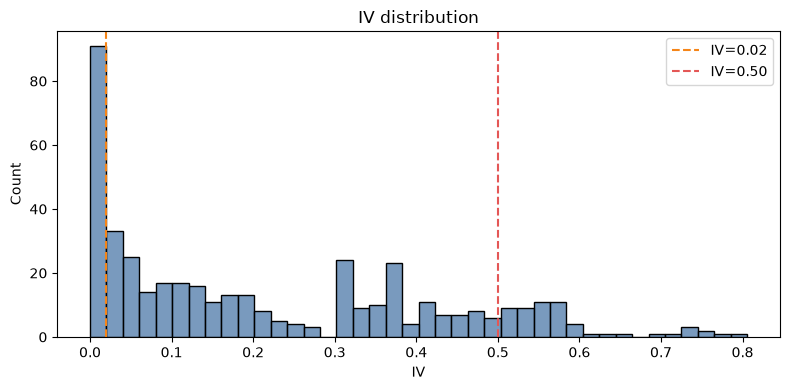

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(iv_table["IV"], bins=40, color="#4C78A8")
plt.axvline(0.02, color="#F58518", linestyle="--", label="IV=0.02")
plt.axvline(0.50, color="#E45756", linestyle="--", label="IV=0.50")
plt.legend()
plt.title("IV distribution")
plt.tight_layout()
plt.show()
